# Boosted Tree Kernel Demo

This notebook checks the `boosted` leaf weighting scheme for scikit-learn Gradient Boosting, XGBoost, or LightGBM classifiers.


In [1]:
from pathlib import Path
import sys


def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "forestkernel").exists():
            return path
    raise RuntimeError("Could not find the project root containing pyproject.toml and forestkernel/.")


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import load_iris
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

from forestkernel import LeafEncoder


In [3]:
seed = 42
boosted_model = "xgb"  # choose: "gbt", "xgb", or "lgbm"
n_estimators = 100
learning_rates = [0.001, 0.003, 0.01, 0.03, 0.1]


def make_boosted_classifier(kind):
    if kind == "gbt":
        return GradientBoostingClassifier(n_estimators=n_estimators, random_state=seed)
    if kind == "xgb":
        from xgboost import XGBClassifier

        return XGBClassifier(
            n_estimators=n_estimators,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=seed,
            verbosity=0,
        )
    if kind == "lgbm":
        from lightgbm import LGBMClassifier

        return LGBMClassifier(
            n_estimators=n_estimators,
            n_jobs=-1,
            random_state=seed,
            verbose=-1,
        )
    raise ValueError(f"Unknown boosted_model={kind!r}.")

base_forest = make_boosted_classifier(boosted_model)


In [4]:
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.2,
    stratify=iris.target,
    random_state=seed,
)

print(f"Train samples: {X_train.shape[0]}; test samples: {X_test.shape[0]}")


Train samples: 120; test samples: 30


In [5]:
kernels = {}
weights = {}
summary = {}

for lr in learning_rates:
    forest = clone(base_forest).set_params(learning_rate=lr)
    encoder = LeafEncoder(forest=forest, weight_scheme="boosted").fit(X_train, y_train)

    K_fast = encoder.kernel(return_dense=True)
    tree_weights = encoder.forest_.get_tree_weights(X_train)
    leaves = encoder.forest_.get_leaf_matrix(X_train)

    K_slow = np.zeros_like(K_fast, dtype=np.float32)
    for t in range(leaves.shape[1]):
        same_leaf = leaves[:, [t]] == leaves[:, [t]].T
        K_slow += tree_weights[t] * same_leaf.astype(np.float32)

    max_error = np.max(np.abs(K_fast - K_slow))
    kernels[lr] = K_fast
    weights[lr] = tree_weights
    summary[lr] = {
        "nnz_frac": np.mean(K_fast > 0),
        "max": K_fast.max(),
        "mean": K_fast.mean(),
        "max_error": max_error,
    }

    print(
        f"lr={lr:<7} "
        f"nnz={summary[lr]['nnz_frac']:.3f} "
        f"Kmax={summary[lr]['max']:.4f} "
        f"Kmean={summary[lr]['mean']:.4f} "
        f"max_error={max_error:.2e}"
    )


lr=0.001   nnz=0.767 Kmax=1.0000 Kmean=0.4570 max_error=2.98e-08
lr=0.003   nnz=0.767 Kmax=1.0000 Kmean=0.4572 max_error=2.98e-08
lr=0.01    nnz=0.767 Kmax=1.0000 Kmean=0.4577 max_error=1.19e-07
lr=0.03    nnz=0.772 Kmax=1.0000 Kmean=0.4516 max_error=2.98e-08
lr=0.1     nnz=1.000 Kmax=1.0000 Kmean=0.4469 max_error=5.96e-08


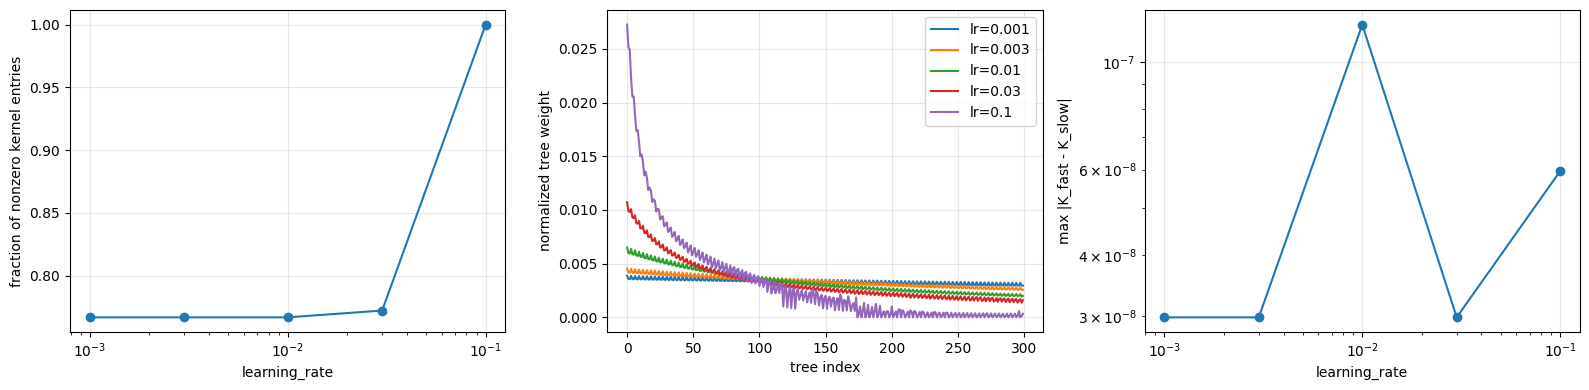

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(learning_rates, [summary[lr]["nnz_frac"] for lr in learning_rates], marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("learning_rate")
axes[0].set_ylabel("fraction of nonzero kernel entries")
axes[0].grid(alpha=0.3)

for lr in learning_rates:
    axes[1].plot(weights[lr], label=f"lr={lr}")
axes[1].set_xlabel("tree index")
axes[1].set_ylabel("normalized tree weight")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(learning_rates, [summary[lr]["max_error"] for lr in learning_rates], marker="o")
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel("learning_rate")
axes[2].set_ylabel("max |K_fast - K_slow|")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

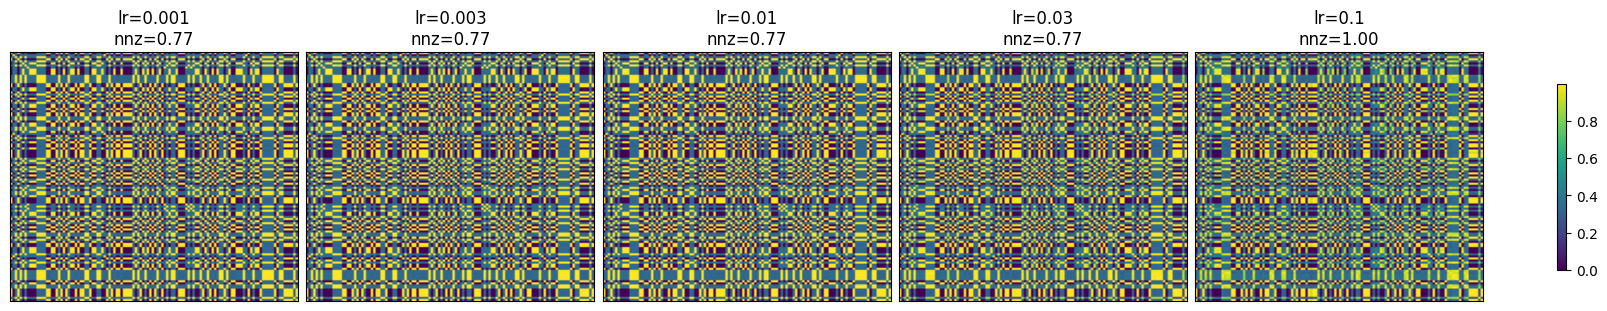

In [7]:
fig, axes = plt.subplots(
    1,
    len(learning_rates),
    figsize=(3.2 * len(learning_rates), 3),
    constrained_layout=True,
)

for ax, lr in zip(np.atleast_1d(axes), learning_rates):
    im = ax.imshow(kernels[lr], aspect="auto")
    ax.set_title(f"lr={lr}\nnnz={summary[lr]['nnz_frac']:.2f}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=np.atleast_1d(axes), shrink=0.75)
plt.show()
